In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

In [2]:
from astroML.datasets import generate_mu_z
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

from sklearn.neighbors import KernelDensity
from astroML.linear_model import NadarayaWatson

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


(35.0, 50.0)

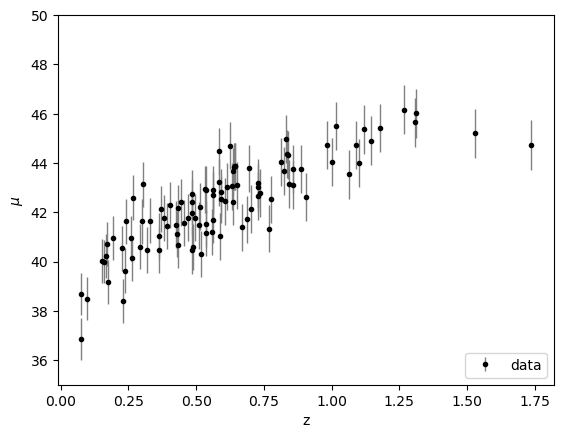

In [4]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [5]:
X = z_sample[:, np.newaxis]
y = mu_sample
dy = dmu

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor

#w/ default kernel

gp = GaussianProcessRegressor()
gp.fit(X,y)

linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_predx, dy_predx = gp.predict(linx, return_std=True)

In [7]:
gp3 = GaussianProcessRegressor()
gp3.fit(X,y)
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

In [8]:
# Constrain the mean and covariance

dy3 = dy

kernel3 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) # Radial-basis function kernel (aka squared-exponential kernel)
gp3 = GaussianProcessRegressor(kernel=kernel3,
                               alpha=dy3**2,
                               random_state=0)
gp3.fit(X,y)

linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

(35.0, 50.0)

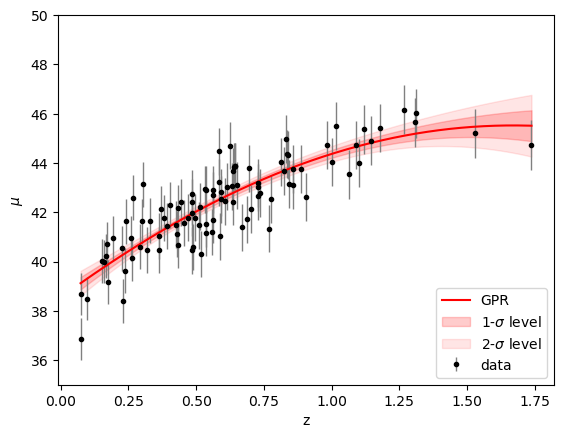

In [9]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#plt.errorbar(z_sample, y_pred, dy_pred, fmt='.r', ecolor='gray', lw=1,label='GPR')
plt.plot(linx, y_predx, color='r', label='GPR')

plt.fill_between(linx[:,0], y_predx - dy_predx, y_predx + dy_predx, color='r', alpha=0.2, label='1-$\sigma$ level')
plt.fill_between(linx[:,0], y_predx - 2*dy_predx, y_predx + 2*dy_predx, color='r', alpha=0.1, label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [10]:
kernels.RBF?

Init signature: kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-05, 100000.0))
Docstring:     
Radial basis function kernel (aka squared-exponential kernel).

The RBF kernel is a stationary kernel. It is also known as the
"squared exponential" kernel. It is parameterized by a length scale
parameter :math:`l>0`, which can either be a scalar (isotropic variant
of the kernel) or a vector with the same number of dimensions as the inputs
X (anisotropic variant of the kernel). The kernel is given by:

.. math::
    k(x_i, x_j) = \exp\left(- \frac{d(x_i, x_j)^2}{2l^2} \right)

where :math:`l` is the length scale of the kernel and
:math:`d(\cdot,\cdot)` is the Euclidean distance.
For advice on how to set the length scale parameter, see e.g. [1]_.

This kernel is infinitely differentiable, which implies that GPs with this
kernel as covariance function have mean square derivatives of all orders,
and are thus very smooth.
See [2]_, Chapter 4, Section 4.2, for further details of the RBF kern

(35.0, 50.0)

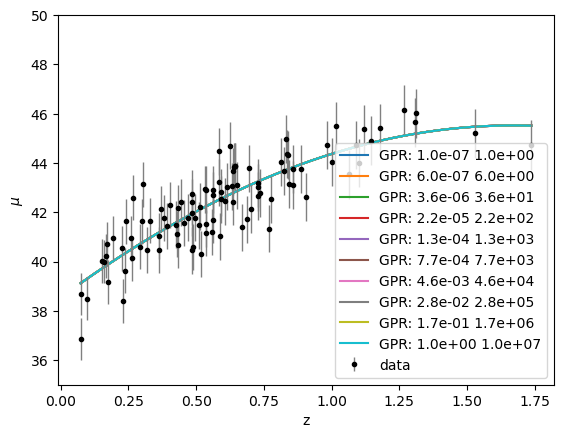

In [11]:
# Constrain the mean and covariance with many noisy points

dy3 = dy
lscales = np.logspace(-4,3,10)
gps = []
for ls in lscales:

    kernel3 = ConstantKernel(1.0, (1e-3, 1e3))*kernels.RBF(ls, (ls/1000, ls*40000))
    gp4 = GaussianProcessRegressor(kernel=kernel3,
                                   alpha=dy3**2,
                                   random_state=0)
    gps = np.append(gps, gp4)
    gp4.fit(X,y)
    y_predx, dy_predx = gp4.predict(linx, return_std=True)
    
    
    plt.plot(linx, y_predx, label='GPR: %.1e %.1e' % (ls/1000, ls*10000)  )

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [12]:
# I should cross validate to find the best kernel 
# When the upper limit is too low the optimal value found for dimension 0 of parameter k2__length_scale is the upper limit
# Similarly when the lower limit is too high
# --> this problem is solved for upper limits always > 4 and 

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [14]:
def geterror(X,y,classifier):
    return np.sqrt( np.sum(( y - classifier.predict(X) )**2) / len(X) )

def fitanderror(classifier):
    classifier.fit(X_train, y_train)
    error_train = geterror(X_train,y_train,classifier)
    error_validation  = geterror(X_validation, y_validation, classifier)
    return error_train, error_validation

In [15]:
etrain, etest= [], []

for i, gpi in zip(lscales, gps): # Corrected loop to get 'i'

    # Update alpha to match the training data's noise variance
    gpi.alpha = dy_train**2
    
    error_train, error_validation = fitanderror(gpi)
    print("Length scale =",i, error_train, error_validation)
    etrain.append(error_train)
    etest.append(error_validation)

print("Best", lscales[np.argmin(etest)], min(etest))

Length scale = 0.0001 0.939232189501297 0.8277053259689339
Length scale = 0.0005994842503189409 0.9392321811204836 0.827705388209263
Length scale = 0.003593813663804626 0.9392321688512041 0.8277054749706192
Length scale = 0.021544346900318846 0.9392321779793119 0.8277054103717654
Length scale = 0.1291549665014884 0.9392321817770138 0.8277053834283853
Length scale = 0.774263682681127 0.9392321895286847 0.8277053250152497
Length scale = 4.641588833612782 0.9392321611165848 0.827705528070983
Length scale = 27.825594022071257 0.939232173093279 0.8277054443107497
Length scale = 166.81005372000593 0.9392321793186691 0.8277054010133926
Length scale = 1000.0 0.9392321798861797 0.8277053963339828
Best 0.774263682681127 0.8277053250152497


Cloning
-

In [16]:
z_vals = np.array(z_sample).reshape(-1, 1) 
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

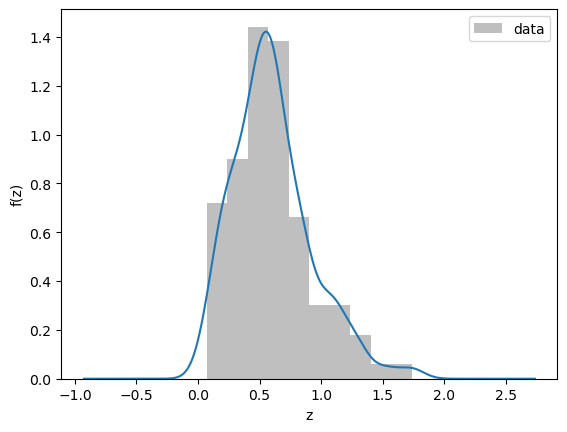

In [17]:
z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)
plt.hist(z_sample, color='gray',alpha=0.5,label='data',density=True)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend();

Text(0.5, 1.0, 'Cloned data')

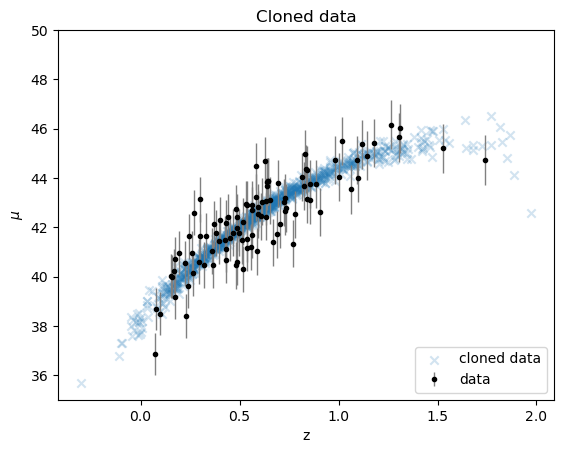

In [18]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gps[np.argmin(etest)].predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
    
plt.scatter(new_z_samples,mu_gpr,alpha=0.2,label='cloned data',marker='x')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)
plt.title("Cloned data")